<a href="https://colab.research.google.com/github/Drei-i/MachineLearningPIT/blob/main/ROCCurve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Rabaya(Burnout_DATASET) - Sheet1.csv to Rabaya(Burnout_DATASET) - Sheet1.csv


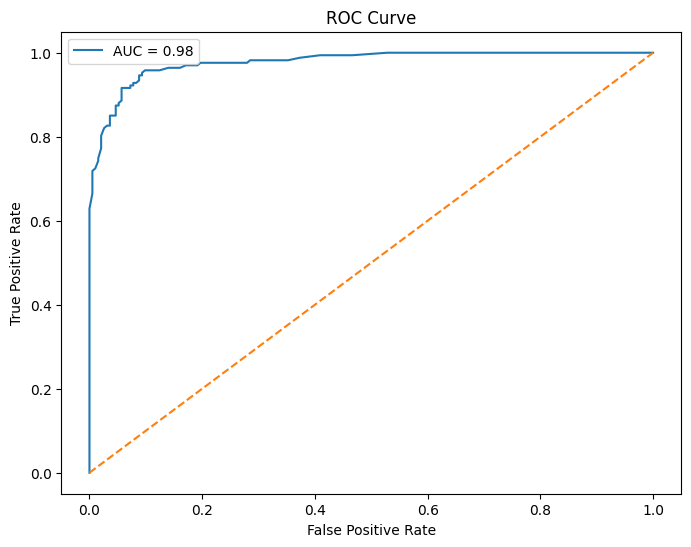

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc

# Load Dataset
from google.colab import files

# Upload Dataset Manually
uploaded = files.upload()

# Read Uploaded CSV File
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Convert Burnout Score into Classes
median_score = df['burnout_score'].median()
df['burnout_class'] = (df['burnout_score'] >= median_score).astype(int)

# Features and Target
X = df[[
    'work_hours',
    'screen_time_hours',
    'meetings_count',
    'breaks_taken',
    'after_hours_work',
    'sleep_hours',
    'task_completion_rate'
]]

y = df['burnout_class']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Probability Scores
y_prob = model.predict_proba(X_test)[:, 1]

# ROC Computation
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()